Importing Libaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import (
    train_test_split, 
    cross_val_score,
    GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

Loading Data

In [2]:
df = pd.read_csv("Kaggle_CreditCard.csv")

print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Exploratory Data Analysis
EDA-Class Distribution

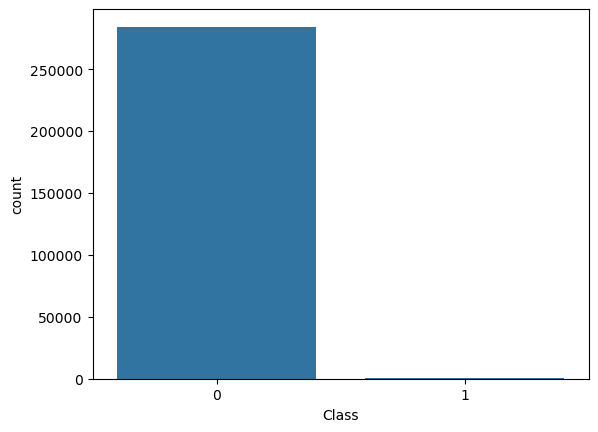

In [3]:
sns.countplot(x='Class', data=df)
plt.savefig("class_distribution.png")
plt.show()

EDA-Amount Distribution

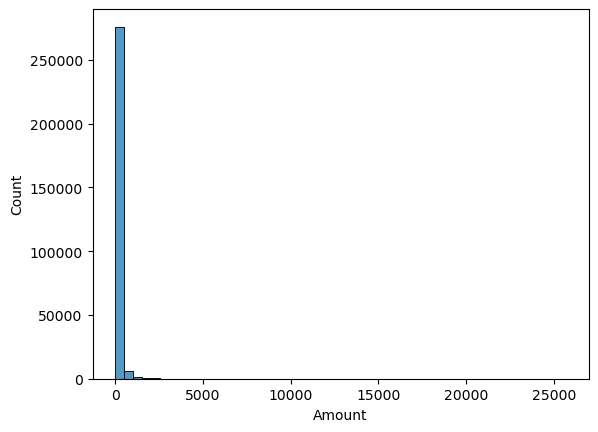

In [4]:
sns.histplot(df['Amount'], bins=50)
plt.savefig("amount_distribution.png")
plt.show()

EDA-Correlation Heatmap

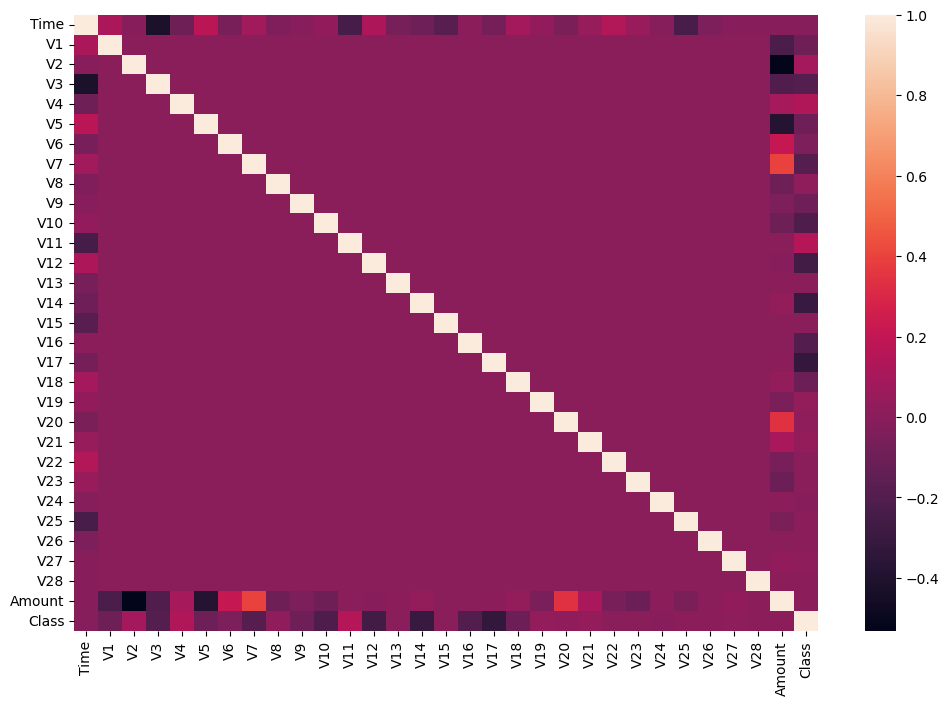

In [5]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr())

plt.savefig(
    "correlation_heatmap.png",
    dpi=300
)

plt.show()

Train-Test Split

In [6]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Scaling ALL Features

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

SMOTE

In [8]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

Models
Logistic Regression

In [9]:
lr = LogisticRegression(
    max_iter=5000,
    solver='liblinear',
    random_state=42
)

Random Forest

In [10]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

XGBoost

In [11]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

Cross Validation

In [12]:
score = cross_val_score(
    xgb,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print(score.mean())

0.9992948503285579


Train Models

In [13]:
models = {
    "Logistic Regression":lr,
    "Random Forest":rf,
    "XGBoost":xgb
}

In [14]:
results = []

for name, model in models.items():

    model.fit(X_train_smote,y_train_smote)

    pred = model.predict(X_test_scaled)
    prob = model.predict_proba(X_test_scaled)[:,1]

    results.append({
        'Model':name,
        'Accuracy':accuracy_score(y_test,pred),
        'Precision':precision_score(y_test,pred),
        'Recall':recall_score(y_test,pred),
        'F1 Score':f1_score(y_test,pred),
        'ROC AUC':roc_auc_score(y_test,prob)
    })

Model Comparison

In [15]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='ROC AUC',
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
1        Random Forest  0.997841   0.435233  0.857143  0.577320  0.982669
2              XGBoost  0.998244   0.494186  0.867347  0.629630  0.978295
0  Logistic Regression  0.974141   0.057878  0.918367  0.108893  0.970810


Classification Report

In [16]:
print(classification_report(
    y_test,
    xgb.predict(X_test_scaled)
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.49      0.87      0.63        98

    accuracy                           1.00     56962
   macro avg       0.75      0.93      0.81     56962
weighted avg       1.00      1.00      1.00     56962



Confusion Matrix

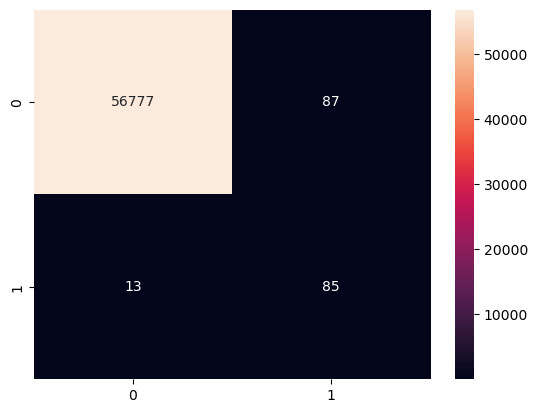

In [17]:
cm = confusion_matrix(
    y_test,
    xgb.predict(X_test_scaled)
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.savefig(
    "confusion_matrix.png"
)

plt.show()

ROC Curve

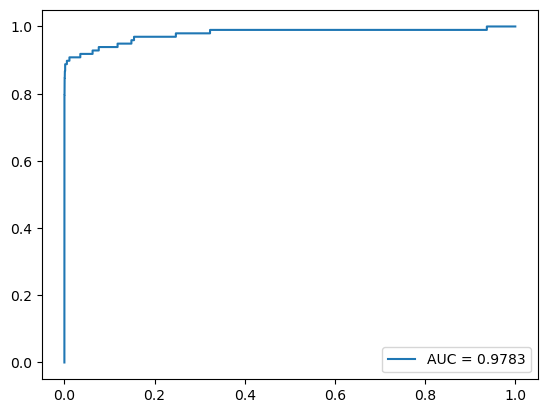

In [18]:
prob = xgb.predict_proba(
    X_test_scaled
)[:,1]

fpr,tpr,_ = roc_curve(
    y_test,
    prob
)

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test,prob):.4f}"
)

plt.legend()

plt.savefig(
    "roc_curve.png"
)

plt.show()

Feature Importance

In [19]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

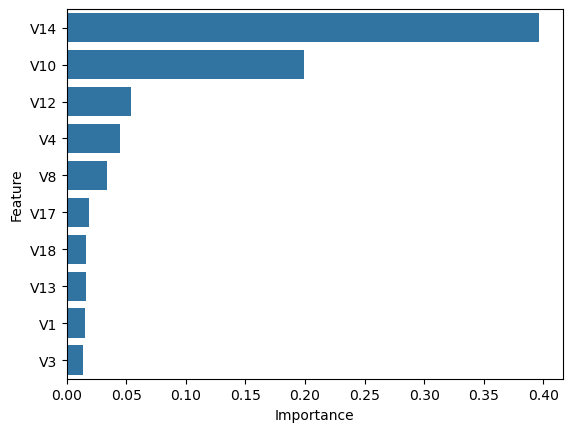

In [20]:
sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.savefig(
    "feature_importance.png"
)

plt.show()

SHAP Explainability

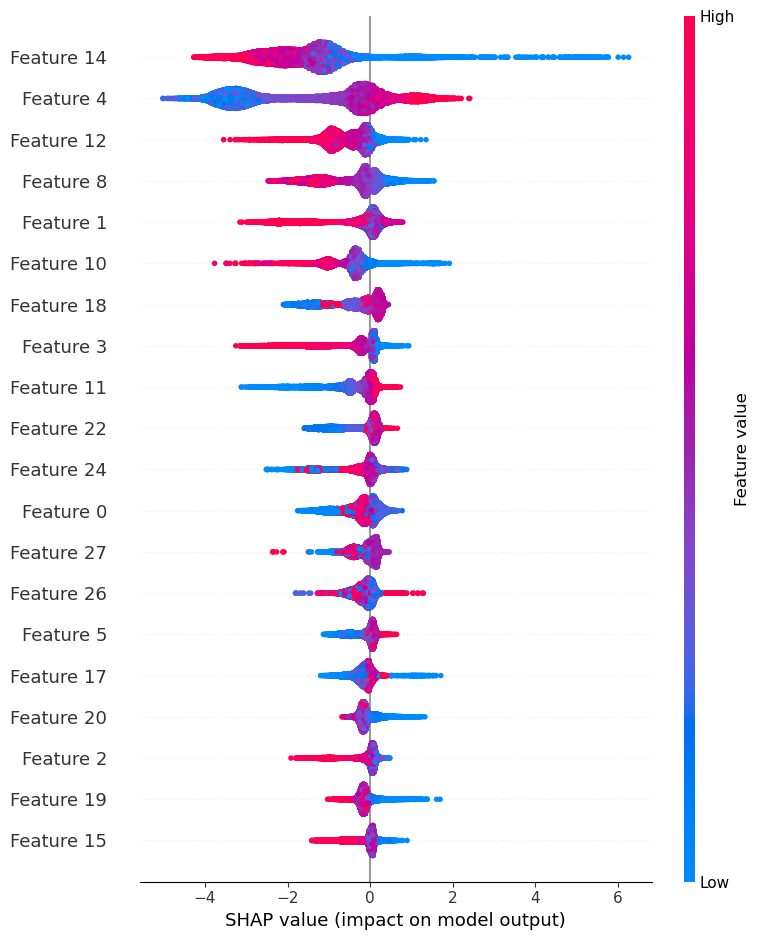

In [21]:
explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(
    X_test_scaled
)

shap.summary_plot(
    shap_values,
    X_test_scaled
)

Save Objects

In [22]:
joblib.dump(
    xgb,
    "fraud_detection_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']